# Reconstruction on the common range and on the extension

Both baselines are compared on identical pixels: within the m/z windows they share, and on the extension of the wide axis, where the question is whether the wide model reconstructs the new range or leaves it empty.

## Introduction

The wide axis quadruples the input dimension at the same latent dimension. Two effects are possible: the extra
range costs capacity (the common range is reconstructed worse than by the narrow model), and the extension
itself is reconstructed poorly (the decoder leaves windows with signal empty). The first is measured with the
within-window cost on common windows, paired per pixel; the second with input and reconstruction masses in the
extension windows.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* Both axes are evaluated on identical pixels (same source spectra), so per-pixel comparisons are paired. The
  models of the two axes are independent; repetition $r$ of one axis is paired with repetition $r$ of the other only
  for convenience (the seeds are equal but the models are not related).
* Global $W_1$ values are not comparable across axes: the wide axis transports intensity over a longer m/z range and
  normalizes by a TIC that includes the extension. Comparisons of reconstruction therefore use the windows shared by
  both axes, where the within-window cost is renormalized and comparable.

        * A window is *emptied* in a pixel when the input holds at least $10^{-3}$ of the TIC there and the
          reconstruction less than $10^{-4}$. Windows without input signal cannot be emptied; zeros there are correct.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Narrow axis $\mathcal{A}_n$ = 200-900 m/z (1273 bins); wide axis $\mathcal{A}_w$ = 100-3000 m/z (5273 bins); common
  windows = 200-300, ..., 800-900; extension windows = 100-200 and 900-3000.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "axis_comparison_reconstruction"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
NARROW, WIDE = metadata.get('narrow_axis', 'axis-200-900'), metadata.get('wide_axis', 'axis-100-3000')
AXIS_LABELS = {axis: catalog[catalog.axis == axis].display_label.iloc[0] for axis in (NARROW, WIDE)}
AXIS_COLORS = {axis: LABEL_COLORS[AXIS_LABELS[axis]] for axis in (NARROW, WIDE)}
DATASETS = sorted(load_table(settings, 'axis_comparison_reconstruction', 'image_maps').dataset_id.unique())
print('Narrow axis:', NARROW, '| wide axis:', WIDE, '| held-out images:', DATASETS)

common = table('common_windows')
extension = table('extension_windows')
maps = table('image_maps')

Analysis: axis_comparison_reconstruction | axis: None | models: 10
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Narrow axis: axis-200-900 | wide axis: axis-100-3000 | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`axis_comparison_reconstruction` reads the per-pixel window arrays of both axes from the `inference` level and pairs them by source spectrum.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis axis_comparison_reconstruction > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis          repetition model_id                                                                                                                                                      
axis-100-3000 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7052  0.5102       4.0381                   0.8771          1.0991        3.2           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6942  0.5129       4.0117                   0.8824          1.0917        2.0            True
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6851  0.4777       3.7285                   0.8647          1.0539        3.4           False
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7068  0.5122       4.0129                   0.8813          1.1247        2.8           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6951  0.5102       4.1471                   0.8816          1.1029        3.6           False
axis-200-900  0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6970  0.4851       3.2834                   0.8835          0.9449        3.0           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6899  0.4772       2.9758                   0.8751          1.0732        4.2           False
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6990  0.5055       3.1069                   0.8918          0.9337        1.4            True
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6947  0.4789       3.1123                   0.9003          0.9509        3.2           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6957  0.4872       3.1081                   0.8833          0.9554        3.2           False

### Remarks

- Maps show repetition 2 (200-900) and repetition 1 (100-3000), the representative models of their axes.

### Notes

## Common windows: narrow versus wide reconstruction

### Methodology

#### Theoretical

For every common window $W$, population and repetition pair: the mean within-window cost of both axes and the
per-pixel paired difference $w_W^{\mathrm{wide}}(x) - w_W^{\mathrm{narrow}}(x)$ (median and fraction of pixels
where the wide model is worse).

#### Implementation

`common_windows` holds, per population, window, quantity and repetition, both means and the paired statistics.

#### Figure descriptions

First figure: x = window, y = mean within-window cost; colour = axis; one point per repetition, held-out
images. Heat map: rows = populations, columns = windows, colour = median paired difference (wide - narrow;
red = wide worse), repetition mean.

window_label,200-300,300-400,400-500,500-600,600-700,700-800,800-900
population,,,,,,,
train,0.881,0.810,0.613,0.512,0.409,0.808,0.685
test,0.885,0.808,0.616,0.509,0.412,0.805,0.685
test_extended,0.768,0.591,0.492,0.591,0.490,0.710,0.744
heldout_image,0.828,0.913,0.703,0.606,0.598,0.903,0.835


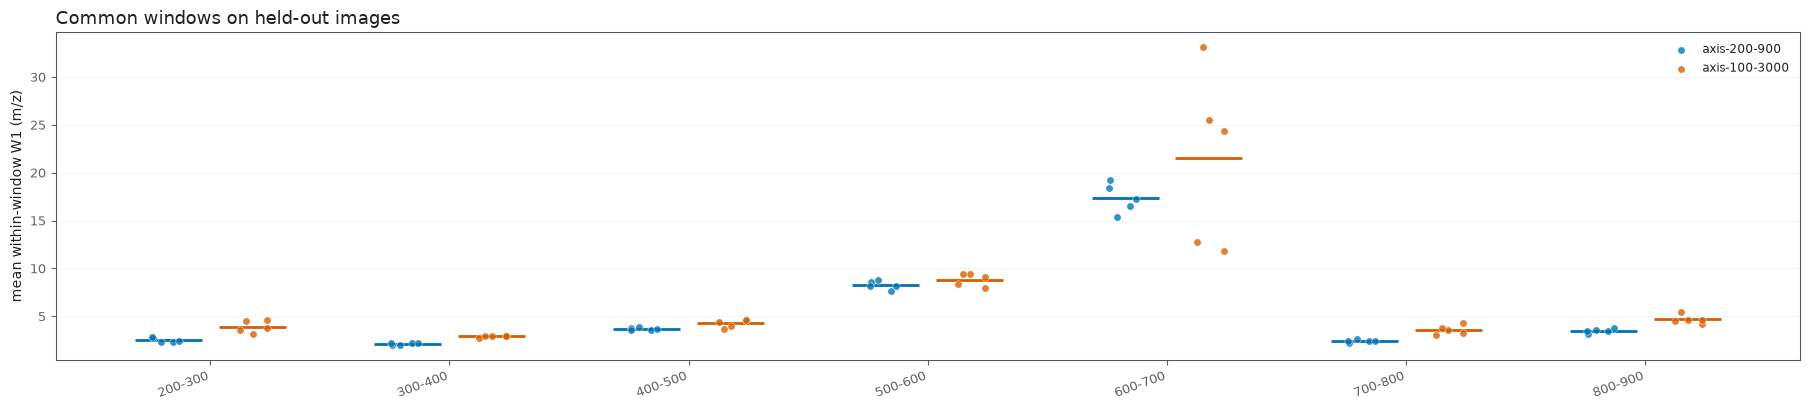

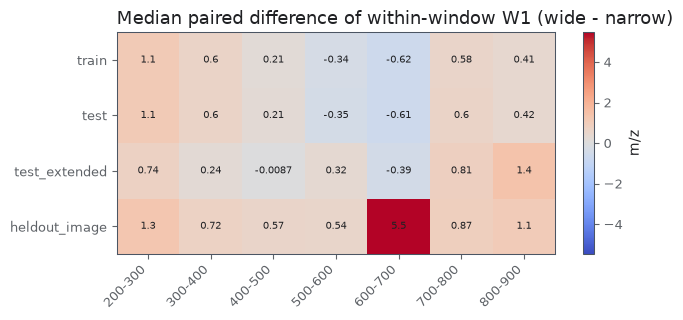

In [4]:
within = common[common.quantity == 'within']
window_order = sorted(within.window_label.unique(), key=lambda label: float(label.split('-')[0]))
long = pd.concat([within.assign(axis=NARROW, value=within.narrow_mean), within.assign(axis=WIDE, value=within.wide_mean)])
figures.repetition_points(long[long.population == 'heldout_image'], value='value', group='window_label', hue='axis', order=window_order, hue_order=[NARROW, WIDE], colors=AXIS_COLORS, ylabel='mean within-window W1 (m/z)', title='Common windows on held-out images', theme=theme);
matrix = within.pivot_table(index='population', columns='window_label', values='median_difference').reindex(index=POPULATIONS, columns=window_order)
figures.matrix_heatmap(matrix, title='Median paired difference of within-window W1 (wide - narrow)', colorbar_label='m/z', diverging=True, annotate=True, theme=theme);
display(within.pivot_table(index='population', columns='window_label', values='wide_larger_fraction').reindex(index=POPULATIONS, columns=window_order).round(3))

### Remarks

- In the peak-rich common windows (200-400, 700-900) the wide model has a higher within-window cost for 80-91 % of train/test pixels (median paired difference +0.4 to +1.1 m/z); in the low-mass windows 500-700 the two axes are equal on train/test.
- On held-out images the wide model is worse in every common window (60-91 % of pixels).

### Notes

## Extension windows of the wide axis

### Methodology

#### Theoretical

For every extension window: mean input mass $M_X(W)$, mean reconstruction mass $M_{\hat X}(W)$, number of
pixels with input signal and the fraction of those pixels the reconstruction empties.

#### Implementation

`extension_windows` holds these per population, window and repetition of the wide models.

#### Figure descriptions

x = window lower edge (m/z, log scale), y = mean TIC fraction; solid = input, dashed = reconstruction; colour =
population; one line per repetition. The table lists windows with input signal.

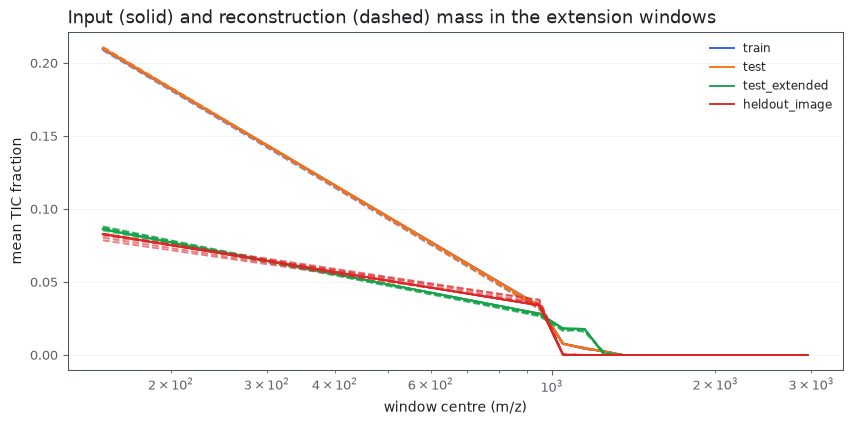

mean_input_mass  mean_output_mass  pixels_with_signal  emptied_fraction
population    window_label                                                                         
heldout_image 100-200                0.0829            0.0813             29433.0            0.0000
              1000-1100              0.0000            0.0003                 9.0            0.2222
              900-1000               0.0340            0.0363             28898.0            0.0000
test          100-200                0.2102            0.2104              3910.0            0.0000
              1000-1100              0.0077            0.0077              1940.0            0.0314
              1100-1200              0.0045            0.0045              1742.0            0.0195
              1200-1300              0.0024            0.0024              1544.0            0.0000
              900-1000               0.0336            0.0323              3576.0            0.0000
test_extended 100-200                0.0862            0.0871              1227.0            0.0000
              1000-1100              0.0181            0.0173               529.0            0.0439
              1100-1200              0.0178            0.0168               492.0            0.0500
              900-1000               0.0284            0.0271               996.0            0.0000
train         100-200                0.2096            0.2099             70417.0            0.0000
              1000-1100              0.0077            0.0077             34882.0            0.0301
              1100-1200              0.0045            0.0045             31397.0            0.0197
              1200-1300              0.0024            0.0024             27788.0            0.0000
              900-1000               0.0337            0.0324             64449.0            0.0000

In [5]:
figure, ax = plt.subplots(figsize=(10, 4.4), dpi=theme.figure_dpi)
for population in POPULATIONS:
    for _, lines in extension[extension.population == population].groupby('repetition'):
        lines = lines.sort_values('window_lower')
        ax.plot(lines.window_lower + 50, lines.mean_input_mass, color=POPULATION_COLORS[population], linewidth=theme.line_width, alpha=theme.secondary_alpha)
        ax.plot(lines.window_lower + 50, lines.mean_output_mass, color=POPULATION_COLORS[population], linestyle='--', linewidth=theme.line_width, alpha=theme.secondary_alpha)
ax.set_xscale('log')
ax.set_xlabel('window centre (m/z)')
ax.set_ylabel('mean TIC fraction')
ax.set_title('Input (solid) and reconstruction (dashed) mass in the extension windows', loc=theme.title_location)
ax.legend(handles=[plt.Line2D([], [], color=POPULATION_COLORS[name], label=name) for name in POPULATIONS], frameon=False)
plt.show()
display(extension[extension.pixels_with_signal > 0].groupby(['population', 'window_label'])[['mean_input_mass', 'mean_output_mass', 'pixels_with_signal', 'emptied_fraction']].mean().round(4))

### Remarks

- 100-200 m/z: input and reconstruction mass agree in every population (0.210 vs 0.210 in training images, 0.083 vs 0.081 in held-out images); no pixel is emptied.
- 900-1300 m/z: mass reproduced; at most 5 % of pixels with signal are emptied (1000-1200 m/z, test extension). Windows above 1300 m/z carry no input signal.

### Notes

## Extension mass per held-out image

### Methodology

#### Theoretical

Per held-out image, the input and reconstruction mass of every extension window with signal.

#### Implementation

`extension_images` (repetition means).

#### Figure descriptions

No figure.

In [6]:
images = table('extension_images')
shown = images[(images.population == 'heldout_image')].groupby(['dataset_id', 'window_label'])[['mean_input_mass', 'mean_output_mass']].mean()
display(shown[shown.mean_input_mass > 1e-4].round(4))

mean_input_mass  mean_output_mass
dataset_id           window_label                                   
2024-02-20_01h45m20s 100-200                0.0859            0.0855
                     900-1000               0.0339            0.0342
2024-02-20_01h46m58s 100-200                0.0942            0.0891
                     900-1000               0.0258            0.0348
2024-02-20_01h54m41s 100-200                0.0659            0.0668
                     900-1000               0.0435            0.0405

### Remarks

### Notes

## Side-by-side maps of both axes

### Methodology

#### Theoretical

Maps of both models on the same held-out pixels: global $W_1$ of each axis (not comparable in value, only in
pattern), the summed contribution of the common windows, the mean within-window cost of the common windows,
and for the wide axis the contribution and masses of the extension windows.

#### Implementation

`image_maps` holds the representative model's values per held-out pixel for both axes (never repetition means).

#### Figure descriptions

First figure: rows = images, columns = narrow $W_1$, wide $W_1$, narrow and wide common-window mean within-window
cost (shared colour range for the last two is not enforced; each column has its own). Second figure: wide-axis
extension contribution, extension input mass and extension reconstruction mass.

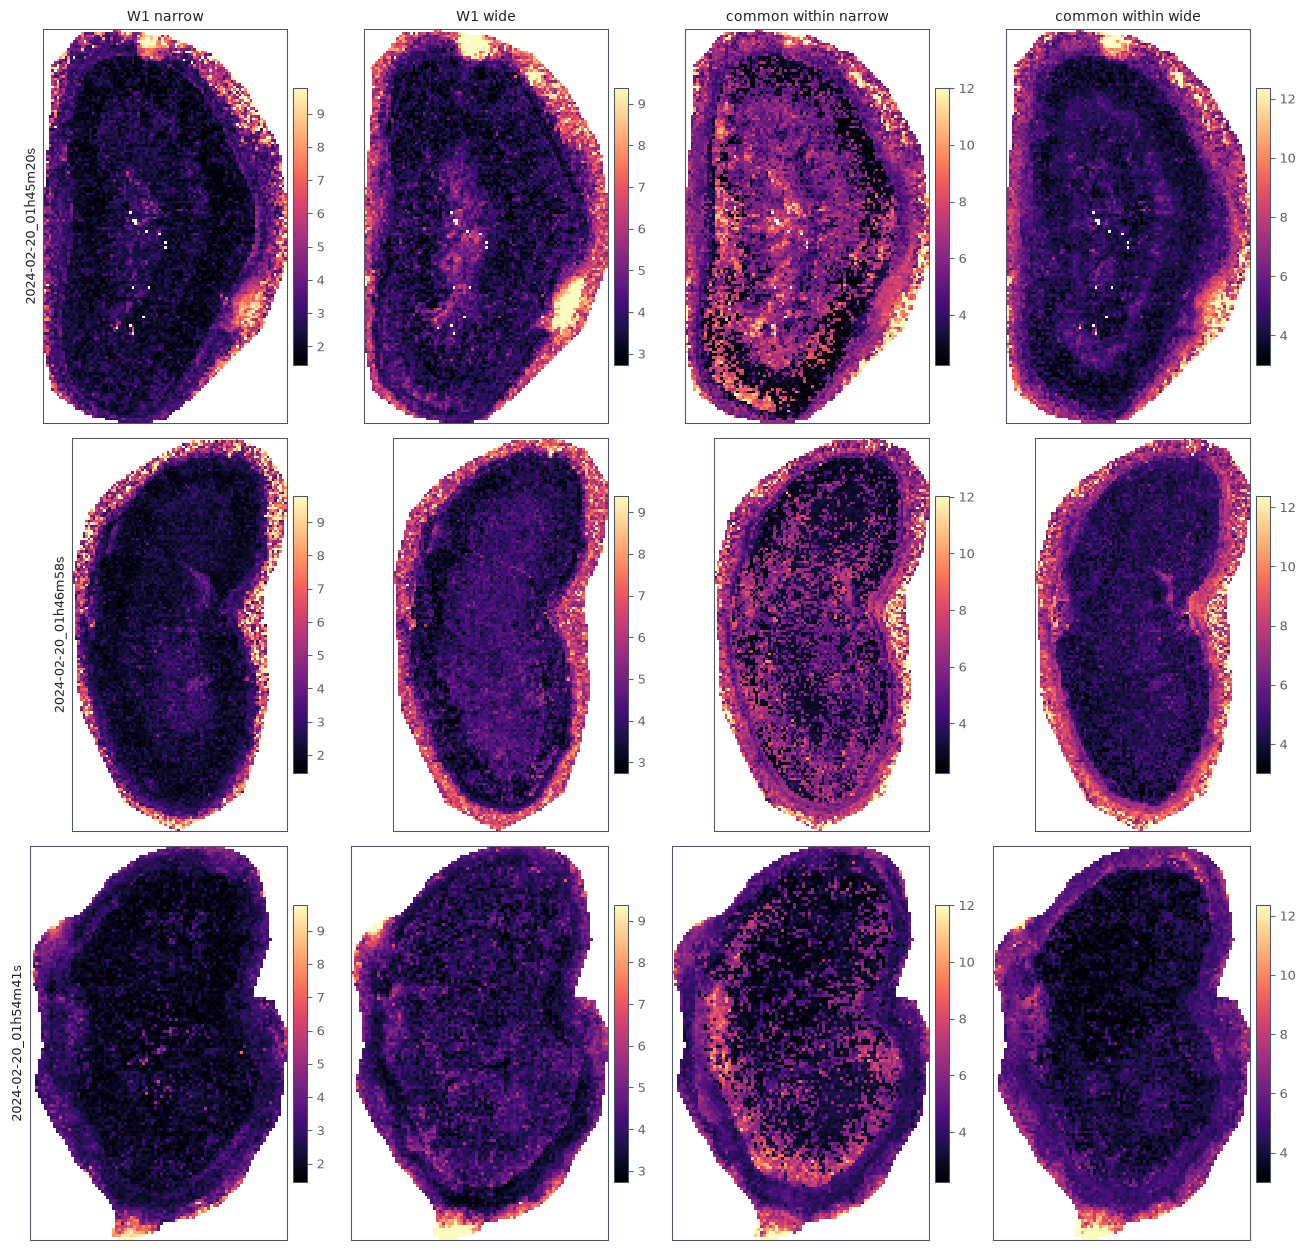

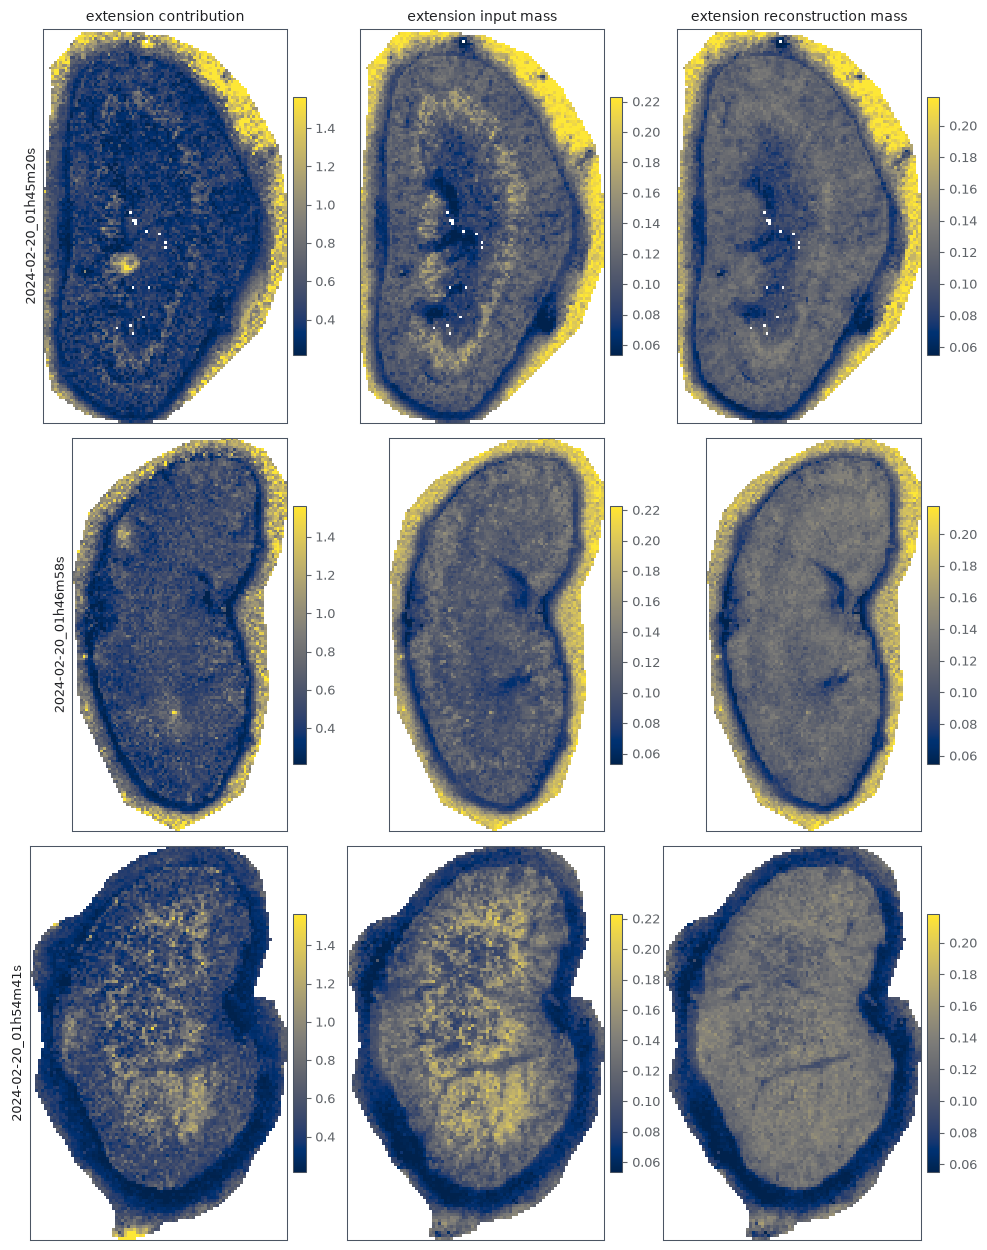

In [7]:
figures.image_panels(maps, value_columns=['masserstein_narrow', 'masserstein_wide', 'common_within_narrow', 'common_within_wide'], column_titles=['W1 narrow', 'W1 wide', 'common within narrow', 'common within wide'], datasets=DATASETS, theme=theme);
figures.image_panels(maps, value_columns=['extension_contribution_wide', 'extension_input_mass_wide', 'extension_output_mass_wide'], column_titles=['extension contribution', 'extension input mass', 'extension reconstruction mass'], datasets=DATASETS, cmap=theme.image_colormap, theme=theme);

### Remarks

- Maps of the representative models. The $W_1$ maps of the two axes agree only partly (Spearman over pixels 0.51-0.64 per image; common-window within-cost 0.49-0.61): both are high at the tissue border, but the ranking of interior pixels differs.

### Notes

## Results / Summary

### LLM

- **Observed:** widening the axis costs reconstruction quality in the common range: the within-window cost of the wide model is higher in the peak-rich windows for 80-90 % of pixels (paired), and on held-out images in every common window.
- **Observed:** the wide model reconstructs the extension: window masses of 100-200 and 900-1300 m/z are reproduced and practically no pixel with signal is emptied. Together with `part_1_05` (extension ions reproduced spatially at 22-42 % intensity), the model flattens but does not delete the new range.
- **Interpretation:** at equal architecture the wider output lowers peak sharpness everywhere; the effect is a decoder/resolution cost, not a failure specific to the new range.
- **Decision relevance:** a pretrained model on the wide axis should be judged against this common-window cost, not only against global W1.

### Person